# Explicabilidad: SHAP sobre los modelos elegidos

## Qué responde este notebook

Un modelo que predice bien sirve de poco si no se puede explicar por qué predijo lo que predijo. Los
tres modelos elegidos en [`4.4_ajuste_hiperparametros.ipynb`](4.4_ajuste_hiperparametros.ipynb) son
XGBoost, así que se usa `shap.TreeExplainer`: un `beeswarm` para la importancia global, un
`waterfall` para explicar un caso real, los peores errores y los casos donde sí acierta. Los modelos
se entrenan con 2016-2021 y se explican sobre la prueba (2024-2025). Las variables están descritas
en el [glosario](../../../docs/data/GLOSARIO_VARIABLES.md).

In [1]:
import sys
sys.path.insert(0, "../src")
import data, features, modeling, experimentos

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from xgboost import XGBRegressor

pd.set_option("display.width", 160)
sns.set_style("whitegrid")
AZUL, NARANJA, VERDE, GRIS, GRIS_CLARO = "#2a78d6", "#eb6834", "#1baf7a", "#888780", "#c3c2b7"

wr = features.construir_tabla_modelado(range(2016, 2026))
features_arbol = features.columnas_por_modelo("arbol")
train_mask, val_mask, test_mask = experimentos.dividir_temporal(
    wr, range(2016, 2022), [2022, 2023], [2024, 2025]
)
X = wr[features_arbol]

CONFIG_ELEGIDA = {
    "receptions": dict(max_depth=3, n_estimators=200, learning_rate=0.03),
    "receiving_yards": dict(max_depth=3, n_estimators=200, learning_rate=0.03),
    "receiving_tds": dict(objective="count:poisson", max_depth=3, n_estimators=200, learning_rate=0.08),
}
MODELOS = {target: XGBRegressor(**config, random_state=0, n_jobs=-1) for target, config in CONFIG_ELEGIDA.items()}
explicaciones = {}
for target, modelo in MODELOS.items():
    modelo.fit(X[train_mask], wr[target][train_mask])
    explainer = shap.TreeExplainer(modelo)
    explicaciones[target] = explainer(X[test_mask])
print("explicaciones calculadas sobre la prueba (2024-2025) para los 3 resultados")

/usr/local/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


explicaciones calculadas sobre la prueba (2024-2025) para los 3 resultados


## 1. `receiving_yards`: importancia global

Hay dos lecturas anteriores con otros métodos: la importancia por permutación de
[`3.2_seleccion_features.ipynb`](3.2_seleccion_features.ipynb), con otro modelo, y la importancia
nativa de este mismo XGBoost en
[`4.2_modelos_recepciones_yardas.ipynb`](4.2_modelos_recepciones_yardas.ipynb).

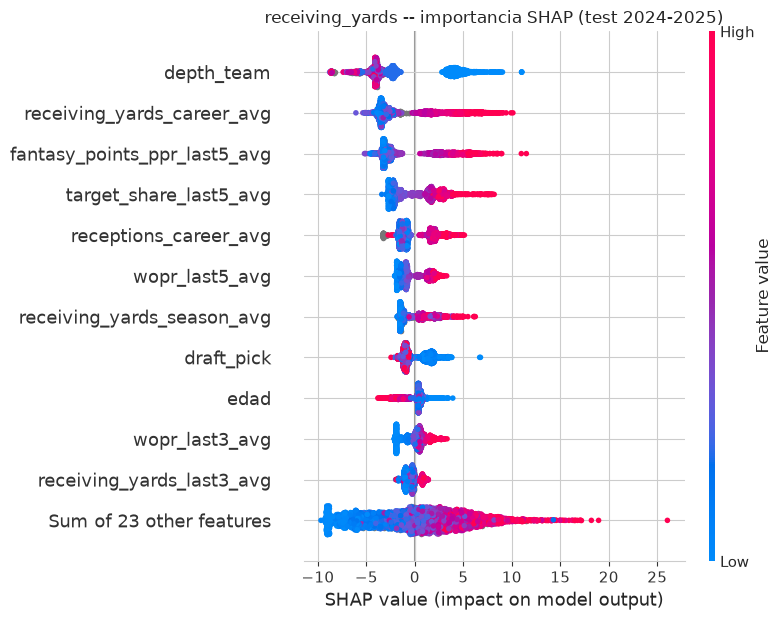

In [2]:
fig = plt.figure(figsize=(8, 6))
shap.plots.beeswarm(explicaciones["receiving_yards"], max_display=12, show=False)
plt.title("receiving_yards -- importancia SHAP (test 2024-2025)")
plt.tight_layout()
plt.show()

**Lectura.** Las variables con más peso en SHAP son `depth_team`, `receiving_yards_career_avg`,
`fantasy_points_ppr_last5_avg`, `target_share_last5_avg`, `receptions_career_avg` y
`wopr_last5_avg` (definiciones en el [glosario](../../../docs/data/GLOSARIO_VARIABLES.md)). Las
otras dos lecturas coinciden solo en parte:

| Método | Las cuatro primeras |
|---|---|
| Importancia por permutación (3.2, otro modelo) | `target_share_last5_avg`, `depth_team`, `receiving_yards_season_avg`, `wopr_last5_avg` |
| Importancia nativa de XGBoost (4.2) | `fantasy_points_ppr_last5_avg`, `wopr_last5_avg`, `target_share_last5_avg`, `receiving_yards_career_avg` |
| SHAP (aquí) | `depth_team`, `receiving_yards_career_avg`, `fantasy_points_ppr_last5_avg`, `target_share_last5_avg` |

Los tres métodos coinciden en la participación reciente (`target_share_last5_avg`, `wopr_last5_avg`)
y en el lugar en la alineación (`depth_team`, sexto en la importancia nativa). El nivel de carrera
pesa en SHAP y en la importancia nativa, pero no aparece entre las 15 primeras por permutación. Esa
medición se hizo en 3.2 con otro modelo (HistGradientBoosting) y 109 candidatas, muchas
correlacionadas entre sí; una explicación posible es que, al permutar una, el modelo se apoya en
otra parecida y la importancia se reparte.

El `beeswarm` agrega la dirección: ser titular (`depth_team` = 1, en azul porque es el
valor más bajo) suma yardas y estar más abajo resta; más participación y mejor carrera suman; la
edad alta resta y una selección temprana en el draft (`draft_pick` bajo) suma.

## 2. `receptions`: importancia global

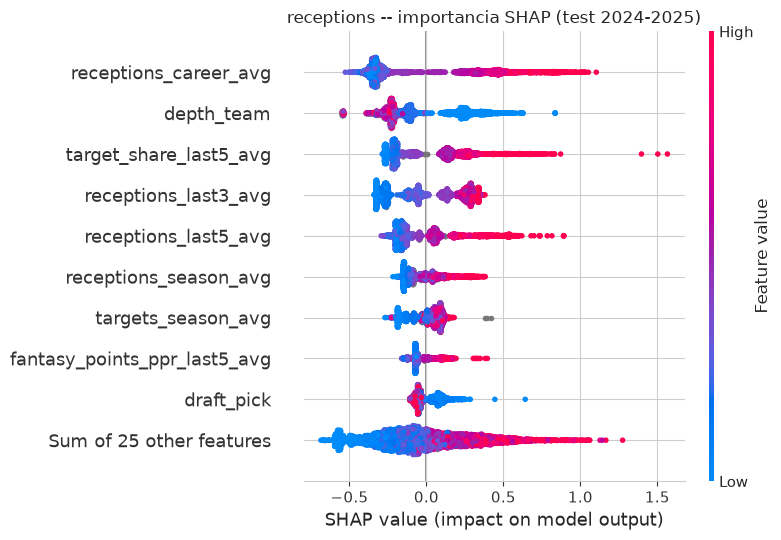

In [3]:
fig = plt.figure(figsize=(8, 6))
shap.plots.beeswarm(explicaciones["receptions"], max_display=10, show=False)
plt.title("receptions -- importancia SHAP (test 2024-2025)")
plt.tight_layout()
plt.show()

**Lectura.** En recepciones manda el nivel de carrera del propio receptor (`receptions_career_avg`), seguido de
`depth_team` y `target_share_last5_avg`, y después sus promedios recientes de recepciones. Es el
mismo patrón que en yardas, con más peso en su propio historial de recepciones.

## 3. `receiving_tds`: importancia global, en escala logarítmica

El modelo de `receiving_tds` usa `objective="count:poisson"`, que trabaja con enlace logarítmico.
Antes de leer el `beeswarm` se verifica con casos reales cómo se relacionan los valores SHAP con la
predicción.

In [4]:
pred_directa = MODELOS["receiving_tds"].predict(X[test_mask])
suma_shap_log = explicaciones["receiving_tds"].values.sum(axis=1) + explicaciones["receiving_tds"].base_values
comparacion_escala = pd.DataFrame({
    "prediccion_real": pred_directa[:5],
    "exp(suma_shap + base)": np.exp(suma_shap_log[:5]),
})
comparacion_escala

,prediccion_real,exp(suma_shap + base)
0,0.336072,0.336071
1,0.263859,0.263859
2,0.257852,0.257852
3,0.236447,0.236447
4,0.262596,0.262596


**Lectura.** En los cinco casos la predicción coincide con `exp(suma de valores SHAP + base)`, salvo
redondeo en el sexto decimal. El modelo trabaja en escala logarítmica, así que los valores SHAP se leen como factores: un valor de +0.2
multiplica la tasa esperada de touchdowns por exp(0.2) = 1.22 (22% más), no le suma 0.2
touchdowns. Así el modelo respeta que la tasa sea siempre positiva.

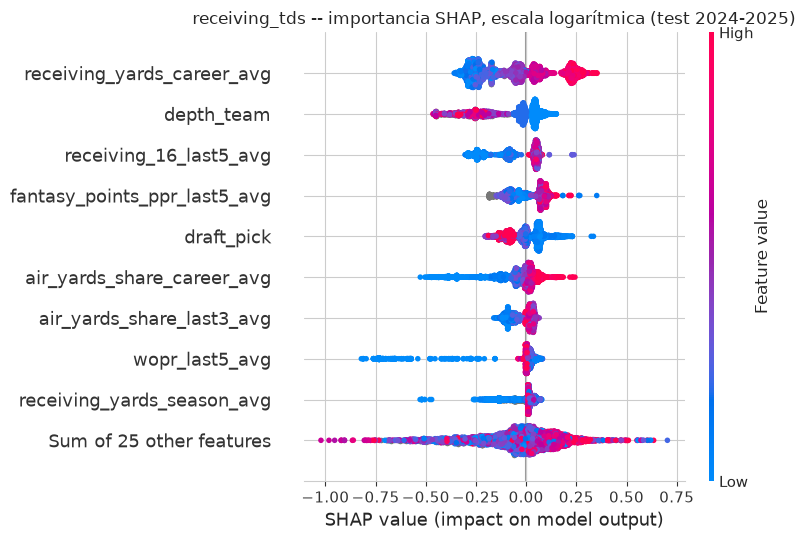

In [5]:
fig = plt.figure(figsize=(8, 6))
shap.plots.beeswarm(explicaciones["receiving_tds"], max_display=10, show=False)
plt.title("receiving_tds -- importancia SHAP, escala logarítmica (test 2024-2025)")
plt.tight_layout()
plt.show()

**Lectura.** Los valores que siguen se leen en la gráfica, así que son aproximados. La variable más
influyente es `receiving_yards_career_avg`: los receptores con mucho historial de yardas llegan a
+0.35 (×1.42). Le siguen `depth_team` (estar más abajo en la alineación llega a
−0.45, ×0.64), `receiving_16_last5_avg` (recepciones recientes de 16 yardas o más),
`fantasy_points_ppr_last5_avg` y `draft_pick`. El efecto individual más grande hacia abajo es
`wopr_last5_avg` bajo, de −0.3 a cerca de −0.8 (×0.74 a ×0.45): receptores sin participación
reciente. En la mayoría de los partidos, cada variable mueve la tasa menos de un tercio hacia arriba
o hacia abajo.

## 4. Un caso real: Ja'Marr Chase, semana 2 de 2025

Explicar una predicción concreta, no solo un promedio: una semana grande de Chase en 2025, la
temporada que [`5.2_benchmark_vs_legado.ipynb`](5.2_benchmark_vs_legado.ipynb) usó para comparar
contra el flujo heredado.

receiving_yards real esa semana: 165, predicción del modelo: 79.6


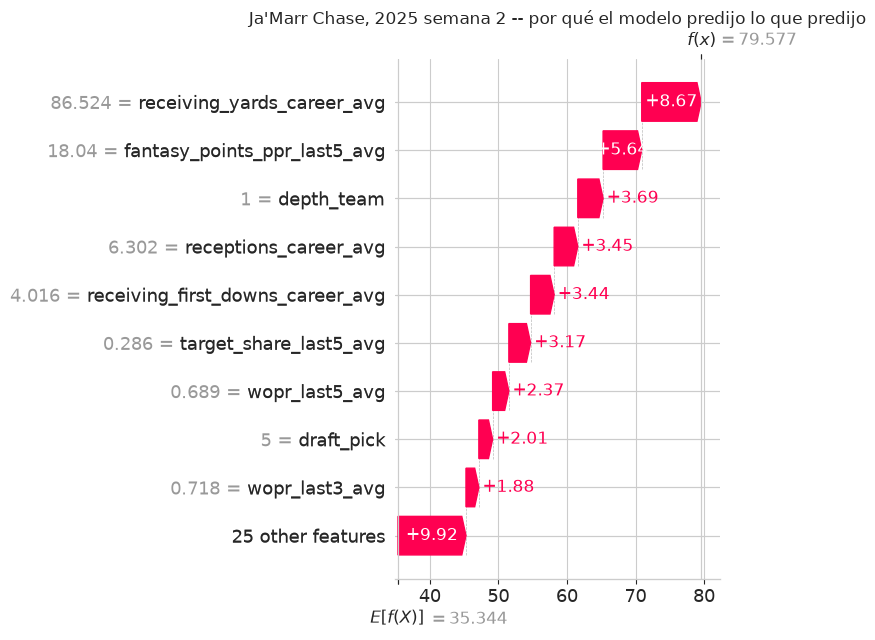

In [6]:
test_df = wr[test_mask].reset_index(drop=True)
chase = test_df[(test_df["player_display_name"] == "Ja'Marr Chase") & (test_df["season"] == 2025) & (test_df["week"] == 2)]
idx_chase = chase.index[0]
print(f"receiving_yards real esa semana: {chase['receiving_yards'].iloc[0]}, predicción del modelo: "
      f"{explicaciones['receiving_yards'][idx_chase].values.sum() + explicaciones['receiving_yards'][idx_chase].base_values:.1f}")

fig = plt.figure(figsize=(8, 5))
shap.plots.waterfall(explicaciones["receiving_yards"][int(idx_chase)], show=False)
plt.title("Ja'Marr Chase, 2025 semana 2 -- por qué el modelo predijo lo que predijo")
plt.tight_layout()
plt.show()

**Lectura.** El modelo predijo 79.6 yardas contra 165 reales. Parte de la predicción promedio (35.3 yardas) y
todas las variables principales empujan hacia arriba: su promedio de carrera de 86.5 yardas
(+8.7), sus puntos de fantasy recientes (+5.6), ser titular (+3.7), sus promedios de carrera de
recepciones y de primeros downs (+3.45 y +3.44) y su participación reciente (+3.2 y +2.4). El modelo reconoce a un
receptor de élite. Lo que no puede anticipar es que esa semana duplicaría lo esperado para ese
perfil: 80 yardas ya es una predicción alta (en la sección 5 casi ninguna predicción pasa de 100), y
él hizo 165.

## 5. Predicho contra real, y los 5 peores errores

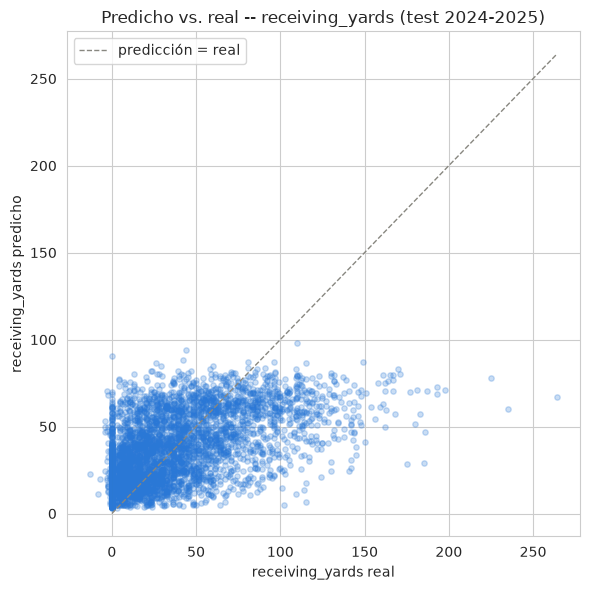

In [7]:
pred_yardas_test = modeling.clip_no_negativo(MODELOS["receiving_yards"].predict(X[test_mask]))
real_yardas_test = wr["receiving_yards"][test_mask].to_numpy()

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(real_yardas_test, pred_yardas_test, alpha=0.25, s=15, color=AZUL)
lim = max(real_yardas_test.max(), pred_yardas_test.max())
ax.plot([0, lim], [0, lim], color=GRIS, linestyle="--", linewidth=1, label="predicción = real")
ax.set_xlabel("receiving_yards real")
ax.set_ylabel("receiving_yards predicho")
ax.set_title("Predicho vs. real -- receiving_yards (test 2024-2025)")
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
test_df_yardas = wr[test_mask].copy()
test_df_yardas["pred"] = pred_yardas_test
test_df_yardas["error"] = test_df_yardas["pred"] - test_df_yardas["receiving_yards"]
peores = test_df_yardas.reindex(test_df_yardas["error"].abs().sort_values(ascending=False).index).head(5)
peores[["player_display_name", "season", "week", "receiving_yards", "pred", "error"]]

,player_display_name,season,week,receiving_yards,pred,error
19288,Ja'Marr Chase,2024,10,264,67.243706,-196.756294
18237,Jerry Jeudy,2024,13,235,59.909798,-175.090202
21487,Michael Wilson,2025,11,185,29.025827,-155.974173
22422,Puka Nacua,2025,16,225,77.904846,-147.095154
17290,Jauan Jennings,2024,3,175,28.189478,-146.810522


**Lectura.** Los 5 peores errores son semanas grandes que el modelo predijo muy por debajo: Chase (264 contra
67.2), Jeudy (235 contra 59.9), Michael Wilson (185 contra 29.0), Nacua (225 contra 77.9) y Jennings
(175 contra 28.2). La gráfica muestra por qué: las predicciones casi no pasan de 100 yardas y lo
real llega a 264. Un modelo de valor esperado no predice semanas atípicas; predice lo que en
promedio produce un receptor con ese perfil.

Esto no es un sesgo del modelo: por cuartil de participación previa la predicción queda a menos de 2
yardas de lo real ([`4.2_modelos_recepciones_yardas.ipynb`](4.2_modelos_recepciones_yardas.ipynb)) y la pendiente
de calibración está cerca de 1 ([`5.1_estabilidad_temporal.ipynb`](5.1_estabilidad_temporal.ipynb)).
Los errores más grandes son subestimaciones porque las yardas tienen piso en cero y una cola larga
hacia arriba: un partido puede quedar 190 yardas por encima de lo esperado, pero nunca 190 por
debajo.

## 6. Casos donde el modelo sí acierta, y qué los distingue

Las secciones 4 y 5 muestran dónde falla el modelo. Esta sección busca lo contrario: ¿en qué
partidos acierta, y por qué?

Dos precauciones. Predecir cerca de 0 yardas para un receptor que terminó con 0 es un acierto
trivial, así que los casos de abajo exigen producción real (60 yardas o más). Y los aciertos más
precisos se eligen, por construcción, entre los mejores; por eso se acompañan de una muestra que no
está elegida por su precisión.

In [9]:
casos = test_df_yardas.reset_index(drop=True)
casos["pred"] = casos["pred"].astype("float64")
casos["error_abs"] = (casos["pred"] - casos["receiving_yards"]).abs()
bandas = pd.cut(
    casos["receiving_yards"], [-np.inf, 20, 50, 100, np.inf], right=False,
    labels=["0-19 yd", "20-49 yd", "50-99 yd", "100+ yd"],
)
resumen_bandas = casos.groupby(bandas, observed=True).agg(
    n=("error_abs", "size"),
    mae=("error_abs", "mean"),
    pct_dentro_de_10_yd=("error_abs", lambda s: (s <= 10).mean() * 100),
    promedio_real=("receiving_yards", "mean"),
    promedio_pred=("pred", "mean"),
)
print(f"en todo el conjunto de prueba ({len(casos)} partidos): a 10 yardas o menos en "
      f"{(casos['error_abs'] <= 10).mean():.1%}, a 20 yardas o menos en {(casos['error_abs'] <= 20).mean():.1%}")
resumen_bandas.round(1)

en todo el conjunto de prueba (4952 partidos): a 10 yardas o menos en 33.7%, a 20 yardas o menos en 61.8%


,n,mae,pct_dentro_de_10_yd,promedio_real,promedio_pred
receiving_yards,,,,,
0-19 yd,2417,16.5,39.0,5.1,21.2
20-49 yd,1304,15.6,37.7,33.1,37.4
50-99 yd,951,23.7,24.9,70.0,49.2
100+ yd,280,67.7,0.0,125.3,57.6


### 6.1 ¿Dónde queda más cerca? Error por banda de yardas reales

En toda la prueba el modelo queda a 10 yardas o menos en 33.7% de los partidos y a 20 yardas o menos
en 61.8%. Por banda de yardas reales, el error es menor en los partidos chicos y medianos (MAE de
16.5 yardas en los de 0-19 y de 15.6 en los de 20-49, con 38-39% de los casos a 10 yardas o menos) y
crece en los grandes (23.7 en los de 50-99 y 67.7 en los de 100 o más, donde ningún partido queda a
10 yardas).

Una precaución de lectura: las bandas se definen por lo que pasó, no por lo que se sabía antes del
partido. Agrupar por el resultado hace parecer que el modelo «sobreestima lo bajo y subestima lo
alto» (5.1 yardas reales contra 21.2 predichas en la primera banda, 125.3 contra 57.6 en la última)
aunque esté calibrado, porque quien terminó con 0 yardas casi siempre tenía una predicción mayor. La
comparación sin ese efecto es la de los cuartiles por participación previa de
[`4.2_modelos_recepciones_yardas.ipynb`](4.2_modelos_recepciones_yardas.ipynb).

In [10]:
UMBRAL = 60
con_produccion = casos[casos["receiving_yards"] >= UMBRAL]
dentro = (con_produccion["error_abs"] <= 10).sum()
print(f"partidos de prueba con >= {UMBRAL} yardas reales: {len(con_produccion)} -- "
      f"el modelo queda a 10 yardas o menos en {dentro} ({dentro / len(con_produccion):.0%})")

columnas_caso = ["player_display_name", "team", "season", "week", "receiving_yards", "pred", "error_abs",
                 "target_share_last5_avg", "depth_team"]
mejores = con_produccion.sort_values("error_abs").head(10)
mejores[columnas_caso].round(2)

partidos de prueba con >= 60 yardas reales: 942 -- el modelo queda a 10 yardas o menos en 141 (15%)


,player_display_name,team,season,week,receiving_yards,pred,error_abs,target_share_last5_avg,depth_team
448,Tyreek Hill,MIA,2025,4,67,66.94,0.06,0.23,1.0
3584,Tank Dell,HOU,2024,3,62,62.06,0.06,0.24,1.0
1681,Justin Jefferson,MIN,2025,8,74,74.07,0.07,0.28,1.0
1799,Tee Higgins,CIN,2024,4,60,60.44,0.44,0.16,1.0
2393,Drake London,ATL,2024,11,61,61.44,0.44,0.24,1.0
1780,Jerry Jeudy,CLE,2024,18,63,63.64,0.64,0.27,1.0
1365,Terry McLaurin,WAS,2025,17,63,62.21,0.79,0.24,1.0
1303,DK Metcalf,SEA,2024,13,66,66.84,0.84,0.23,1.0
2223,Amon-Ra St. Brown,DET,2024,3,75,75.85,0.85,0.30,1.0
689,Chris Godwin Jr.,TB,2024,4,69,68.12,0.88,0.27,1.0


### 6.2 Los aciertos más precisos

De 942 partidos de prueba con 60 yardas o más, el modelo queda a 10 yardas o menos en 141 (15%). Los
10 de arriba son los más precisos, con menos de 1 yarda de error: muestran el mejor caso, no el
típico.

Lo que tienen en común: son titulares con participación sostenida (`target_share_last5_avg` entre
0.16 y 0.30; los diez con `depth_team` = 1), y su producción real, de 60 a 75 yardas, cae justo en lo
que el modelo espera de un receptor principal con ese perfil. El modelo acierta cuando el partido es el
partido esperable de ese tipo de receptor.

In [11]:
tipicos = casos.groupby(bandas, observed=True, group_keys=False).sample(2, random_state=0)
tipicos[columnas_caso].sort_values("receiving_yards").round(2)

,player_display_name,team,season,week,receiving_yards,pred,error_abs,target_share_last5_avg,depth_team
2974,Xavier Smith,LA,2024,18,0,4.75,4.75,0.00,3.0
1229,Greg Dortch,ARI,2025,9,0,16.09,16.09,0.08,4.0
1919,Rashod Bateman,BAL,2025,4,24,41.04,17.04,0.19,2.0
1867,Tyler Johnson,NYJ,2025,3,32,16.48,15.52,0.08,3.0
3723,Zay Flowers,BAL,2024,15,53,63.75,10.75,0.26,1.0
905,Christian Kirk,JAX,2024,4,61,44.88,16.12,0.15,1.0
1407,A.J. Brown,PHI,2025,12,110,67.16,42.84,0.26,1.0
1808,Tee Higgins,CIN,2024,17,131,68.27,62.73,0.26,1.0


### 6.3 Una muestra que no está elegida por su precisión

Dos partidos al azar (semilla fija) de cada banda de yardas reales. Cinco de los ocho tienen entre 11
y 17 yardas de error. Uno es muy preciso (4.8 yardas: un receptor sin participación que terminó con
0) y dos son errores grandes (A.J. Brown, 110 reales contra 67.2 predichas; Tee Higgins, 131 contra
68.3), ambos titulares con partidos fuertes, el patrón de la sección 5. La precisión de 1 yarda de la
tabla anterior es la excepción, no lo que se puede esperar de un partido cualquiera.

DJ Moore (CHI), 2025 semana 1 -- la de más participación: real 68, predicho 69.2, target_share_last5_avg 0.317


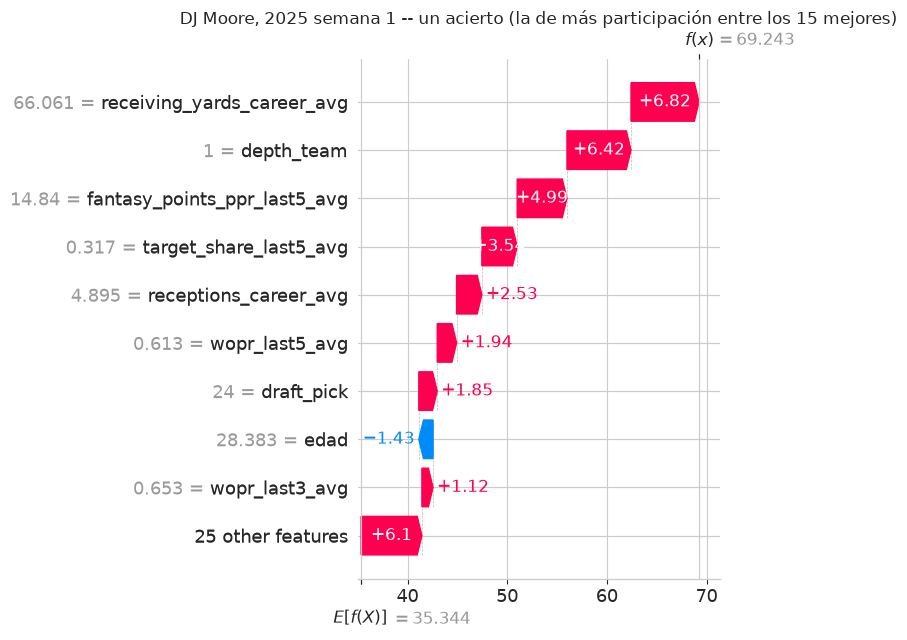

Tee Higgins (CIN), 2024 semana 4 -- la de menos participación: real 60, predicho 60.4, target_share_last5_avg 0.156


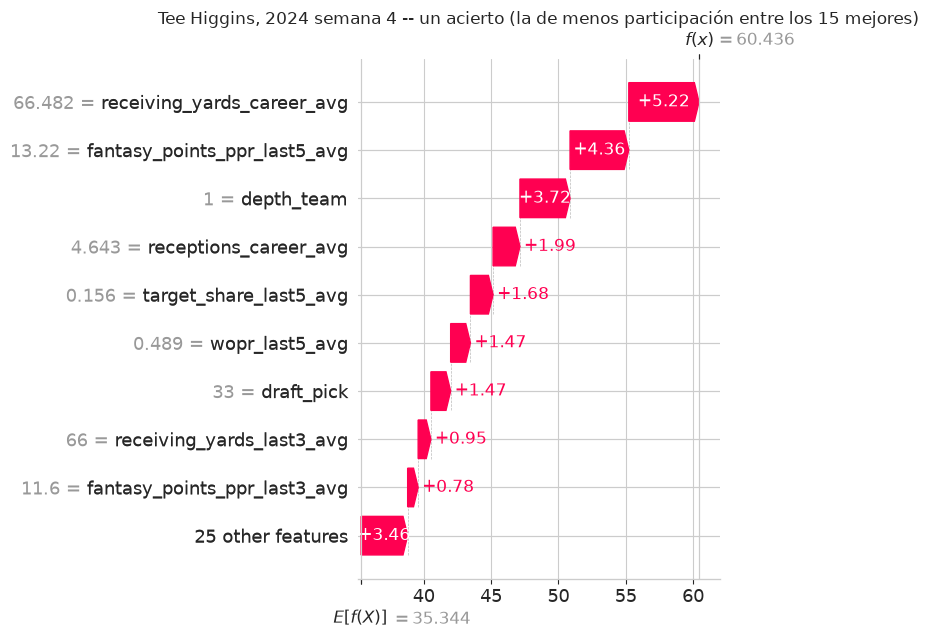

In [12]:
candidatos = con_produccion.sort_values("error_abs").head(15)
casos_waterfall = [
    ("la de más participación", candidatos.sort_values("target_share_last5_avg", ascending=False).iloc[0]),
    ("la de menos participación", candidatos.sort_values("target_share_last5_avg").iloc[0]),
]
for etiqueta, fila in casos_waterfall:
    pos = int(fila.name)
    print(f"{fila['player_display_name']} ({fila['team']}), {int(fila['season'])} semana {int(fila['week'])} -- {etiqueta}: "
          f"real {fila['receiving_yards']:.0f}, predicho {fila['pred']:.1f}, "
          f"target_share_last5_avg {fila['target_share_last5_avg']:.3f}")
    fig = plt.figure(figsize=(8, 5))
    shap.plots.waterfall(explicaciones["receiving_yards"][pos], show=False)
    plt.title(f"{fila['player_display_name']}, {int(fila['season'])} semana {int(fila['week'])} -- un acierto ({etiqueta} entre los 15 mejores)")
    plt.tight_layout()
    plt.show()

### 6.4 Por qué acierta: dos de esos casos

Los dos extremos de participación entre los 15 aciertos más precisos: DJ Moore en la semana 1 de 2025
(`target_share_last5_avg` de 0.317) y Tee Higgins en la semana 4 de 2024 (0.156). En ambos el modelo
parte de la predicción promedio de 35.3 yardas y llega a la suya acumulando evidencia de «titular
consolidado»: promedio de carrera de yardas (66.1 y 66.5), `depth_team` = 1, puntos de fantasy
recientes y participación reciente. Ninguna variable decide sola y ninguna aporta más de 7 yardas. En
Higgins, con menos participación, la cuota de envíos aporta menos (+1.7 contra +3.5 en Moore) y el
resto del perfil compensa; en Moore, su edad (28 años) resta un poco (−1.4).

No hay un truco detrás de estos aciertos: hay un perfil claro y un partido que lo confirma. Es la
otra cara de las secciones 4 y 5, donde el partido se sale del perfil.

## Cierre

- **Tres métodos, coincidencia parcial.** Permutación (3.2), importancia nativa (4.2) y SHAP
  coinciden en la participación reciente (`target_share_last5_avg`, `wopr_last5_avg`) y en
  `depth_team`. El nivel de carrera pesa en SHAP y en la importancia nativa, pero no en la
  permutación de 3.2, hecha con otro modelo y muchas candidatas correlacionadas.
- **Touchdowns se lee en escala multiplicativa.** Con objetivo Poisson, un valor SHAP es un factor
  sobre la tasa esperada, no touchdowns sumados.
- **Dónde falla y dónde acierta.** El modelo predice el valor esperado de un perfil: acierta cuando el
  partido es el típico de ese receptor y se queda corto en las semanas atípicas, que por la forma de
  la distribución (piso en cero, cola larga) son las de producción muy alta. No es un sesgo: por
  participación previa queda a menos de 2 yardas de lo real (4.2) y la pendiente de calibración está cerca de 1 (5.1). Para
  uso en piso o techo hay que mirar un rango, como el de
  [`4.5_regresion_cuantiles.ipynb`](4.5_regresion_cuantiles.ipynb), no solo el valor esperado.

Anterior: [`5.2_benchmark_vs_legado.ipynb`](5.2_benchmark_vs_legado.ipynb) · Siguiente:
[`6.1_modelo_final_y_temporada_actual.ipynb`](6.1_modelo_final_y_temporada_actual.ipynb)